# EDA para toma de decissión
Aquí definiré la variable objetivo al entender la limpieza de mis datos, la distribución y multiples metricas estadisticas

## Datos

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as datetime

In [2]:
ruta = "../data/Streaming_History_Audio_2026.json"

df = pd.read_json(ruta)
df.head()

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2025-12-17T02:30:15Z,windows,238423,MX,2806:2f0:a7e1:fe5b:e80b:6db9:a0d7:912a,Jenga (Cuando Te Dejaba Ganar),Procrastinación 1 Yo 0,Caídas y Vueltas,spotify:track:5BLRVVXNBbOfepvtTBi75t,NaN,...,NaN,NaN,NaN,trackdone,logout,True,False,False,1765938376,0.0
1,2026-01-01T12:46:23Z,ios,82327,MX,189.203.193.241,Do Nothin' Till You Hear From Me - 1956 Version,Billie Holiday,Ben Webster's Finest Hour,spotify:track:1UJJ2S9LLjOdSRV5GcKsZe,NaN,...,NaN,NaN,NaN,trackdone,unexpected-exit-while-paused,False,False,False,1767221154,0.0
2,2026-01-02T18:24:41Z,windows,192467,MX,136.226.112.100,slow,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:4aaiI9YCt4KucUsMmLfGOx,NaN,...,NaN,NaN,NaN,fwdbtn,trackdone,False,False,False,1767378088,0.0
3,2026-01-02T18:28:18Z,windows,217573,MX,136.226.112.100,thorn,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:4JX851uapk8BbbZ6ZkNIHn,NaN,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1767378279,0.0
4,2026-01-02T18:31:48Z,windows,210360,MX,136.226.112.100,cigarette in your bed,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:7cQcEUO7KLVciSS5LqzoyZ,NaN,...,NaN,NaN,NaN,trackdone,trackdone,False,False,False,1767378497,0.0


## Inspección estructural

In [3]:
df.shape

(10589, 23)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10589 entries, 0 to 10588
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ts                                 10589 non-null  object 
 1   platform                           10589 non-null  object 
 2   ms_played                          10589 non-null  int64  
 3   conn_country                       10589 non-null  object 
 4   ip_addr                            10589 non-null  object 
 5   master_metadata_track_name         10589 non-null  object 
 6   master_metadata_album_artist_name  10589 non-null  object 
 7   master_metadata_album_album_name   10589 non-null  object 
 8   spotify_track_uri                  10589 non-null  object 
 9   episode_name                       0 non-null      float64
 10  episode_show_name                  0 non-null      float64
 11  spotify_episode_uri                0 non-null      flo

Al observar que 'ts' se encuentra en object se transforma a datetime para poder utilizarla

In [5]:
df['ts'] = pd.to_datetime(df['ts'])
print(df.dtypes)

ts                                   datetime64[ns, UTC]
platform                                          object
ms_played                                          int64
conn_country                                      object
ip_addr                                           object
master_metadata_track_name                        object
master_metadata_album_artist_name                 object
master_metadata_album_album_name                  object
spotify_track_uri                                 object
episode_name                                     float64
episode_show_name                                float64
spotify_episode_uri                              float64
audiobook_title                                  float64
audiobook_uri                                    float64
audiobook_chapter_uri                            float64
audiobook_chapter_title                          float64
reason_start                                      object
reason_end                     

se transforman los datos de ts a datos mas entendibles de día y hora

In [6]:
# convertimos de UTC a MX
df['ts'] = df['ts'].dt.tz_convert('America/Mexico_City')

df['day_of_week'] = df['ts'].dt.dayofweek 
df['hour'] = df['ts'].dt.hour

df[['ts', 'day_of_week', 'hour', 'skipped']].head()

,ts,day_of_week,hour,skipped
0,2025-12-16 20:30:15-06:00,1,20,False
1,2026-01-01 06:46:23-06:00,3,6,False
2,2026-01-02 12:24:41-06:00,4,12,False
3,2026-01-02 12:28:18-06:00,4,12,False
4,2026-01-02 12:31:48-06:00,4,12,False


In [7]:
df.head()

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,day_of_week,hour
0,2025-12-16 20:30:15-06:00,windows,238423,MX,2806:2f0:a7e1:fe5b:e80b:6db9:a0d7:912a,Jenga (Cuando Te Dejaba Ganar),Procrastinación 1 Yo 0,Caídas y Vueltas,spotify:track:5BLRVVXNBbOfepvtTBi75t,NaN,...,NaN,trackdone,logout,True,False,False,1765938376,0.0,1,20
1,2026-01-01 06:46:23-06:00,ios,82327,MX,189.203.193.241,Do Nothin' Till You Hear From Me - 1956 Version,Billie Holiday,Ben Webster's Finest Hour,spotify:track:1UJJ2S9LLjOdSRV5GcKsZe,NaN,...,NaN,trackdone,unexpected-exit-while-paused,False,False,False,1767221154,0.0,3,6
2,2026-01-02 12:24:41-06:00,windows,192467,MX,136.226.112.100,slow,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:4aaiI9YCt4KucUsMmLfGOx,NaN,...,NaN,fwdbtn,trackdone,False,False,False,1767378088,0.0,4,12
3,2026-01-02 12:28:18-06:00,windows,217573,MX,136.226.112.100,thorn,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:4JX851uapk8BbbZ6ZkNIHn,NaN,...,NaN,trackdone,trackdone,False,False,False,1767378279,0.0,4,12
4,2026-01-02 12:31:48-06:00,windows,210360,MX,136.226.112.100,cigarette in your bed,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:7cQcEUO7KLVciSS5LqzoyZ,NaN,...,NaN,trackdone,trackdone,False,False,False,1767378497,0.0,4,12


In [8]:
df.isnull().sum()

ts                                       0
platform                                 0
ms_played                                0
conn_country                             0
ip_addr                                  0
master_metadata_track_name               0
master_metadata_album_artist_name        0
master_metadata_album_album_name         0
spotify_track_uri                        0
episode_name                         10589
episode_show_name                    10589
spotify_episode_uri                  10589
audiobook_title                      10589
audiobook_uri                        10589
audiobook_chapter_uri                10589
audiobook_chapter_title              10589
reason_start                             0
reason_end                               0
shuffle                                  0
skipped                                  0
offline                                  0
offline_timestamp                        0
incognito_mode                           3
day_of_week

al observar variables con muchos nulos hacemos drop

In [9]:
columnas_null = [
    "episode_name", 
    "episode_show_name", 
    "spotify_episode_uri", 
    "audiobook_title", 
    "audiobook_uri", 
    "audiobook_chapter_uri", 
    "audiobook_chapter_title"
]

df = df.drop(columns=columnas_null)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10589 entries, 0 to 10588
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype                              
---  ------                             --------------  -----                              
 0   ts                                 10589 non-null  datetime64[ns, America/Mexico_City]
 1   platform                           10589 non-null  object                             
 2   ms_played                          10589 non-null  int64                              
 3   conn_country                       10589 non-null  object                             
 4   ip_addr                            10589 non-null  object                             
 5   master_metadata_track_name         10589 non-null  object                             
 6   master_metadata_album_artist_name  10589 non-null  object                             
 7   master_metadata_album_album_name   10589 non-null  object 

evaluate object values to see if we can do one-hot encoding to get more corr on variables

In [10]:
obj_cols = [
    "platform",
    "conn_country",
    "ip_addr",
    "master_metadata_track_name",
    "master_metadata_album_artist_name",
    "master_metadata_album_album_name",
    "spotify_track_uri",
    "reason_start",
    "reason_end"
]

valores_unicos_df = {}

for col in obj_cols:
    valores_unicos_df[col] = df[col].dropna().unique().tolist()
    print("\nValores unicos de ", col)
    print(valores_unicos_df[col])
    print("Cantidad de unicos: ", df[col].nunique())



Valores unicos de  platform
['windows', 'ios', 'osx', 'unknown']
Cantidad de unicos:  4

Valores unicos de  conn_country
['MX', 'US']
Cantidad de unicos:  2

Valores unicos de  ip_addr
['2806:2f0:a7e1:fe5b:e80b:6db9:a0d7:912a', '189.203.193.241', '136.226.112.100', '165.225.218.173', '2806:2f0:a7e1:fe5b:3cd7:85e4:6a01:90fc', '2806:2f0:a7e1:fe5b:c474:aa60:a167:653d', '2806:2f0:a7e1:fe5b:94e4:dcd9:805b:7cf2', '2806:2f0:a7e1:fe5b:5928:af52:f7c1:eb3a', '187.188.10.211', '2806:2f0:a7e1:fe5b:20b9:195b:828d:470c', '136.226.112.91', '2806:2f0:a7e1:fe5b:d020:9e2:58f7:7ab0', '148.244.203.162', '136.226.0.164', '170.85.66.205', '2806:2f0:a7e1:fe5b:81c:8d84:edad:7f35', '136.226.112.83', '136.226.0.194', '2806:2f0:a7e1:fe5b:643f:398a:af9f:2a5d', '2806:2f0:a7e1:fe5b:4544:47f9:5594:1da6', '148.244.203.166', '2806:2f0:a7e1:fe5b:3571:70a4:8517:7187', '2806:2f0:a7e1:fe5b:9120:e576:96e2:c425', '136.226.112.99', '136.226.0.199', '2806:2f0:a7e1:fe5b:3819:e7e8:ad19:a8af', '148.244.203.168', '148.244.203.16

### Frequency encoding y label encoding para artistas

In [11]:
diccionario_frecuencias = df['master_metadata_album_artist_name'].value_counts().to_dict()

artistas_unicos = df['master_metadata_album_artist_name'].dropna().unique()
diccionario_ids = {artista: idx for idx, artista in enumerate(artistas_unicos)}

df['artist_frequency'] = df['master_metadata_album_artist_name'].map(diccionario_frecuencias)
df['artist_id'] = df['master_metadata_album_artist_name'].map(diccionario_ids)

df.head()

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,day_of_week,hour,artist_frequency,artist_id
0,2025-12-16 20:30:15-06:00,windows,238423,MX,2806:2f0:a7e1:fe5b:e80b:6db9:a0d7:912a,Jenga (Cuando Te Dejaba Ganar),Procrastinación 1 Yo 0,Caídas y Vueltas,spotify:track:5BLRVVXNBbOfepvtTBi75t,trackdone,logout,True,False,False,1765938376,0.0,1,20,54,0
1,2026-01-01 06:46:23-06:00,ios,82327,MX,189.203.193.241,Do Nothin' Till You Hear From Me - 1956 Version,Billie Holiday,Ben Webster's Finest Hour,spotify:track:1UJJ2S9LLjOdSRV5GcKsZe,trackdone,unexpected-exit-while-paused,False,False,False,1767221154,0.0,3,6,27,1
2,2026-01-02 12:24:41-06:00,windows,192467,MX,136.226.112.100,slow,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:4aaiI9YCt4KucUsMmLfGOx,fwdbtn,trackdone,False,False,False,1767378088,0.0,4,12,108,2
3,2026-01-02 12:28:18-06:00,windows,217573,MX,136.226.112.100,thorn,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:4JX851uapk8BbbZ6ZkNIHn,trackdone,trackdone,False,False,False,1767378279,0.0,4,12,108,2
4,2026-01-02 12:31:48-06:00,windows,210360,MX,136.226.112.100,cigarette in your bed,my bloody valentine,ep’s 1988-1991 and rare tracks,spotify:track:7cQcEUO7KLVciSS5LqzoyZ,trackdone,trackdone,False,False,False,1767378497,0.0,4,12,108,2


In [12]:
# guardando el diccionario de frecuencias y labels
with open('../data/mapeo_artistas.json', 'w', encoding='utf-8') as f:
    json.dump(diccionario_ids, f, ensure_ascii=False, indent=4)

In [13]:
columnas_texto = [
    'master_metadata_album_artist_name', 
    'master_metadata_track_name', 
    'master_metadata_album_album_name'
]
df = df.drop(columns=columnas_texto)

df.head()

,ts,platform,ms_played,conn_country,ip_addr,spotify_track_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,day_of_week,hour,artist_frequency,artist_id
0,2025-12-16 20:30:15-06:00,windows,238423,MX,2806:2f0:a7e1:fe5b:e80b:6db9:a0d7:912a,spotify:track:5BLRVVXNBbOfepvtTBi75t,trackdone,logout,True,False,False,1765938376,0.0,1,20,54,0
1,2026-01-01 06:46:23-06:00,ios,82327,MX,189.203.193.241,spotify:track:1UJJ2S9LLjOdSRV5GcKsZe,trackdone,unexpected-exit-while-paused,False,False,False,1767221154,0.0,3,6,27,1
2,2026-01-02 12:24:41-06:00,windows,192467,MX,136.226.112.100,spotify:track:4aaiI9YCt4KucUsMmLfGOx,fwdbtn,trackdone,False,False,False,1767378088,0.0,4,12,108,2
3,2026-01-02 12:28:18-06:00,windows,217573,MX,136.226.112.100,spotify:track:4JX851uapk8BbbZ6ZkNIHn,trackdone,trackdone,False,False,False,1767378279,0.0,4,12,108,2
4,2026-01-02 12:31:48-06:00,windows,210360,MX,136.226.112.100,spotify:track:7cQcEUO7KLVciSS5LqzoyZ,trackdone,trackdone,False,False,False,1767378497,0.0,4,12,108,2


### One hot encoding
**Aplicado a platform, reason_start, reason_end, y conn_country**
Dado que estas variables tienen baja cardinalidad y nos ayuda a entnder mejor los compportamientos de reproducción

In [14]:
columnas_baja_cardinalidad = [
    'platform', 
    'reason_start', 
    'reason_end', 
    'conn_country'
    ]

df = pd.get_dummies(df, columns=columnas_baja_cardinalidad, dtype=int)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10589 entries, 0 to 10588
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype                              
---  ------                                   --------------  -----                              
 0   ts                                       10589 non-null  datetime64[ns, America/Mexico_City]
 1   ms_played                                10589 non-null  int64                              
 2   ip_addr                                  10589 non-null  object                             
 3   spotify_track_uri                        10589 non-null  object                             
 4   shuffle                                  10589 non-null  bool                               
 5   skipped                                  10589 non-null  bool                               
 6   offline                                  10589 non-null  bool                               
 7   offl

,ts,ms_played,ip_addr,spotify_track_uri,shuffle,skipped,offline,offline_timestamp,incognito_mode,day_of_week,...,reason_end_endplay,reason_end_fwdbtn,reason_end_logout,reason_end_remote,reason_end_trackdone,reason_end_trackerror,reason_end_unexpected-exit,reason_end_unexpected-exit-while-paused,conn_country_MX,conn_country_US
0,2025-12-16 20:30:15-06:00,238423,2806:2f0:a7e1:fe5b:e80b:6db9:a0d7:912a,spotify:track:5BLRVVXNBbOfepvtTBi75t,True,False,False,1765938376,0.0,1,...,0,0,1,0,0,0,0,0,1,0
1,2026-01-01 06:46:23-06:00,82327,189.203.193.241,spotify:track:1UJJ2S9LLjOdSRV5GcKsZe,False,False,False,1767221154,0.0,3,...,0,0,0,0,0,0,0,1,1,0
2,2026-01-02 12:24:41-06:00,192467,136.226.112.100,spotify:track:4aaiI9YCt4KucUsMmLfGOx,False,False,False,1767378088,0.0,4,...,0,0,0,0,1,0,0,0,1,0
3,2026-01-02 12:28:18-06:00,217573,136.226.112.100,spotify:track:4JX851uapk8BbbZ6ZkNIHn,False,False,False,1767378279,0.0,4,...,0,0,0,0,1,0,0,0,1,0
4,2026-01-02 12:31:48-06:00,210360,136.226.112.100,spotify:track:7cQcEUO7KLVciSS5LqzoyZ,False,False,False,1767378497,0.0,4,...,0,0,0,0,1,0,0,0,1,0


### Limpieza final de colunas que no aportan

In [15]:
# 1. Descartar variables no matemáticas o redundantes
columnas_basura = [
    'ts', 
    'ip_addr', 
    'spotify_track_uri', 
    'offline_timestamp'
    ]

df = df.drop(columns=columnas_basura)

#transformando bools an int
df['incognito_mode'] = df['incognito_mode'].fillna(0).astype(int)
columnas_bool = ['shuffle', 'skipped', 'offline']
df[columnas_bool] = df[columnas_bool].astype(int)

columnas = [col for col in df.columns if col != 'skipped'] + ['skipped']
df = df[columnas]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10589 entries, 0 to 10588
Data columns (total 33 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   ms_played                                10589 non-null  int64
 1   shuffle                                  10589 non-null  int64
 2   offline                                  10589 non-null  int64
 3   incognito_mode                           10589 non-null  int64
 4   day_of_week                              10589 non-null  int32
 5   hour                                     10589 non-null  int32
 6   artist_frequency                         10589 non-null  int64
 7   artist_id                                10589 non-null  int64
 8   platform_ios                             10589 non-null  int64
 9   platform_osx                             10589 non-null  int64
 10  platform_unknown                         10589 non-null  int64
 11  pl

## ydata profilling section

In [16]:
%pip install -U ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [17]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [18]:
import ydata_profiling as pp
pp.ProfileReport(df)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_37036\2977676246.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  import ydata_profiling as pp


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 33/33 [00:00<00:00, 139.00it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
correlaciones = df.corr()['skipped'].abs().sort_values(ascending=False)

print("Correlación de las variables con 'skipped':")
print(correlaciones)

Correlación de las variables con 'skipped':
skipped                                    1.000000
reason_end_trackdone                       0.850034
reason_end_endplay                         0.839248
ms_played                                  0.565621
reason_end_fwdbtn                          0.428262
reason_start_trackdone                     0.406518
reason_start_clickrow                      0.301602
reason_start_fwdbtn                        0.230422
reason_end_backbtn                         0.178289
platform_ios                               0.101703
platform_osx                               0.096042
reason_end_unexpected-exit-while-paused    0.089850
artist_frequency                           0.078193
reason_start_appload                       0.072395
reason_start_backbtn                       0.065990
reason_start_unknown                       0.056066
day_of_week                                0.050766
reason_end_remote                          0.048183
platform_unknown    

In [20]:
reporte = pp.ProfileReport(df, title="EDA Historial Spotify")
# Exportamos a JSON en lugar de HTML
reporte.to_file("../docs/reporte_exploratorio.json")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 33/33 [00:00<00:00, 123.58it/s]
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1 4 6 ... 1 1 1]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[8 2 5 ... 6 6 6]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(


Render JSON:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Análisis y Justificación de la Variable Objetivo

**Hipótesis Inicial ($H_0$):** 
El modelo será capaz de predecir si una canción será saltada (variable objetivo $y$ = `skipped`) basándose en el contexto temporal de la reproducción (`hour`, `day_of_week`), el entorno tecnológico (`platform_ios`, `platform_osx`), la motivación de inicio (`reason_start_*`) y el nivel de preferencia hacia el artista (`artist_frequency`).

**Definición de la Variable Objetivo ($y$)**
Originalmente, se evaluó la posibilidad de predecir el artista exacto a escuchar. Sin embargo, el Análisis Exploratorio de Datos (EDA) reveló una cardinalidad extrema de 725 artistas únicos. En la implementación de un Árbol de Decisión nativo, esto generaría una maldición de la dimensionalidad y un sobreajuste (*overfitting*) inminente. 
Al cambiar la variable objetivo a `skipped` (1 o 0), el problema se transforma en una tarea de clasificación binaria altamente optimizada para el cálculo manual de la Impureza de Gini o Ganancia de Información.

**Selección de Variables Predictoras ($X_i$)**
Las variables de entrada fueron seleccionadas en base a su varianza y distribución observada en el EDA:
* **Contexto Temporal (`hour`, `day_of_week`):** Presentan una distribución amplia. Por ejemplo, `hour` cubre las 24 horas del día con una media de 14.19, lo que permite al modelo identificar clústeres de comportamiento (ej. trayectos vs. horas de estudio).
* **Entorno de Reproducción (`platform`):** Se conservaron las plataformas con mayor densidad matemática (`ios` y `osx`), descartando valores residuales como `platform_unknown` (con un desbalance extremo del 0.995) para evitar ruido computacional.
* **Frequency Encoding (`artist_frequency`):** Se reemplazó el ID del artista por su frecuencia de reproducción anual. Esto convierte un dato categórico masivo en una variable continua que el algoritmo interpreta como el "nivel de afinidad", optimizando la velocidad de convergencia del árbol.

### Prevención de Fuga de Datos (Data Leakage)

Para garantizar la integridad predictiva del modelo, se eliminaron estrictamente las variables `ms_played` y `reason_end_*`. Ambas variables representan la culminación del evento (el "cómo" y el "cuándo" terminó la canción); incluirlas equivaldría a darle la respuesta al modelo durante el entrenamiento, invalidando su capacidad real de predicción predictiva basada en el contexto inicial.

In [21]:
columnas_reason_end = [col for col in df.columns if col.startswith('reason_end_')]
columnas_fuga_datos = columnas_reason_end + ['ms_played']
df = df.drop(columns=columnas_fuga_datos)
print("Columnas eliminadas exitosamente para evitar Data Leakage:")
for col in columnas_fuga_datos:
    print(f"- {col}")

print("\nEstructura final limpia:")
df.info()

Columnas eliminadas exitosamente para evitar Data Leakage:
- reason_end_backbtn
- reason_end_endplay
- reason_end_fwdbtn
- reason_end_logout
- reason_end_remote
- reason_end_trackdone
- reason_end_trackerror
- reason_end_unexpected-exit
- reason_end_unexpected-exit-while-paused
- ms_played

Estructura final limpia:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10589 entries, 0 to 10588
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   shuffle                  10589 non-null  int64
 1   offline                  10589 non-null  int64
 2   incognito_mode           10589 non-null  int64
 3   day_of_week              10589 non-null  int32
 4   hour                     10589 non-null  int32
 5   artist_frequency         10589 non-null  int64
 6   artist_id                10589 non-null  int64
 7   platform_ios             10589 non-null  int64
 8   platform_osx             10589 non-null  int64
 9

### Graficos

C:\Users\Usuario\AppData\Local\Temp\ipykernel_37036\394502144.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='skipped', palette='viridis', ax=axes[0, 0])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_37036\394502144.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='skipped', y='artist_frequency', palette='Set2', ax=axes[1, 1])


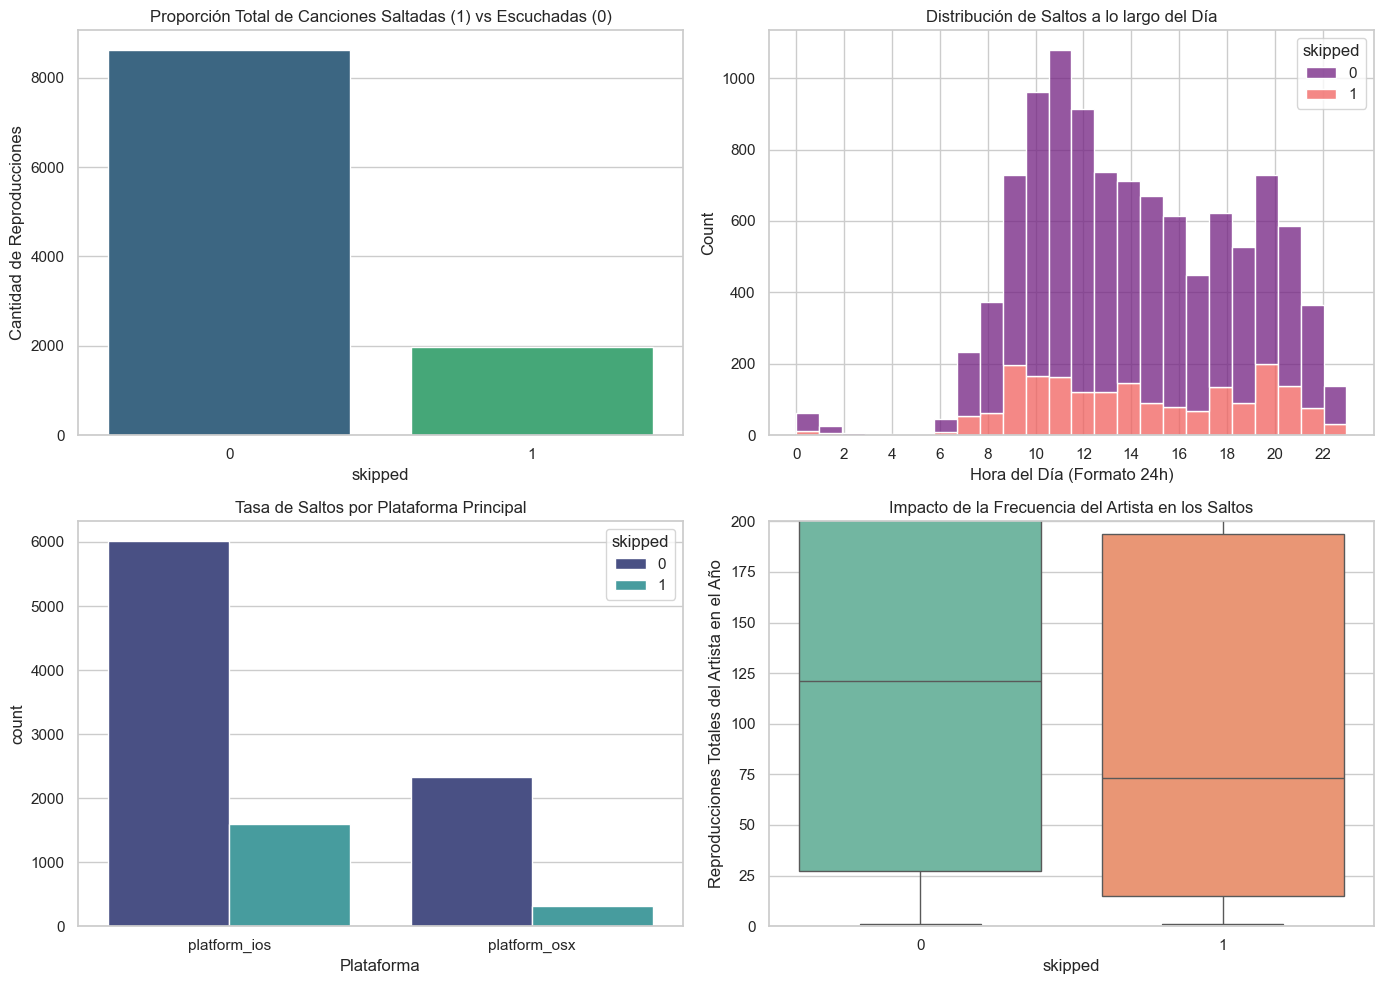

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2)

# 1. Distribución general de la variable objetivo
sns.countplot(data=df, x='skipped', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Proporción Total de Canciones Saltadas (1) vs Escuchadas (0)')
axes[0, 0].set_ylabel('Cantidad de Reproducciones')

# 2. Comportamiento de saltos por Hora del Día
sns.histplot(data=df, x='hour', hue='skipped', multiple='stack', bins=24, palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de Saltos a lo largo del Día')
axes[0, 1].set_xlabel('Hora del Día (Formato 24h)')
axes[0, 1].set_xticks(range(0, 24, 2))

# 3. Plataforma vs Variable Objetivo (Asumiendo que tienes platform_ios y platform_osx)
# Filtramos solo para ver iOS y OSX
df_plat = df[['skipped', 'platform_ios', 'platform_osx']].melt(id_vars='skipped', var_name='Plataforma', value_name='Activo')
df_plat = df_plat[df_plat['Activo'] == 1]
sns.countplot(data=df_plat, x='Plataforma', hue='skipped', palette='mako', ax=axes[1, 0])
axes[1, 0].set_title('Tasa de Saltos por Plataforma Principal')

# 4. Frecuencia del Artista vs Saltos (Boxplot para ver si saltas más a los artistas que menos escuchas)
sns.boxplot(data=df, x='skipped', y='artist_frequency', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Impacto de la Frecuencia del Artista en los Saltos')
axes[1, 1].set_ylabel('Reproducciones Totales del Artista en el Año')
# Hacemos un límite en Y (ej. 200) para que los artistas top no aplasten la visualización del resto
axes[1, 1].set_ylim(0, 200) 

plt.tight_layout()
plt.show()